In [58]:
import numpy as pd
import pandas as pd
import seaborn as sns

In [59]:
temp_df = pd.read_csv("/Users/prathamsharma/Desktop/ML_Dataset/IMDB Dataset.csv")

In [60]:
df= temp_df.iloc[:10000]

In [61]:
print(df.shape)

(10000, 2)


In [62]:
print(df.head(10))

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


In [63]:
df["review"][1] #needs pre-processing

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [64]:
df["sentiment"].value_counts()

sentiment
positive    5028
negative    4972
Name: count, dtype: int64

In [65]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(17)

In [67]:
df.drop_duplicates(inplace=True)

/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_17242/3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [68]:
print(df.shape)

df.duplicated().sum()

(9983, 2)


np.int64(0)

REMOVE TAGS

In [69]:
import re

def remove_tags(raw_text):
    cleaned_text = re.sub(re.compile( "<.*?>" ),"", raw_text) # sub here means substitute which us re.sub(pattern, replacement, string)
    return cleaned_text

In [70]:
df["review"] = df["review"].apply(remove_tags)

/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_17242/3946800833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review"] = df["review"].apply(remove_tags)


In [71]:
print(df["review"][1])

A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.


LOWER CASING

In [72]:
def lower_case(text):
    lowercased_text = text.lower()
    return lowercased_text

In [73]:
df["review"] = df["review"].apply(lower_case)

print(df.head(10))

                                              review sentiment
0  one of the other reviewers has mentioned that ...  positive
1  a wonderful little production. the filming tec...  positive
2  i thought this was a wonderful way to spend ti...  positive
3  basically there's a family where a little boy ...  negative
4  petter mattei's "love in the time of money" is...  positive
5  probably my all-time favorite movie, a story o...  positive
6  i sure would like to see a resurrection of a u...  positive
7  this show was an amazing, fresh & innovative i...  negative
8  encouraged by the positive comments about this...  negative
9  if you like original gut wrenching laughter yo...  positive


/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_17242/2949510700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review"] = df["review"].apply(lower_case)


REMOVE STOP WORDS

In [74]:
from nltk.corpus import stopwords

In [75]:
sw_list = stopwords.words("English")
print(sw_list)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [76]:
from nltk.tokenize import word_tokenize

def remove_stop_words(text):
    words = word_tokenize(text)  # split into words
    
    filtered_words = []
    
    for word in words:
        if word not in sw_list:
            filtered_words.append(word)
    
    return " ".join(filtered_words)

In [77]:
df["review"] = df["review"].apply(remove_stop_words)

/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_17242/343174620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review"] = df["review"].apply(remove_stop_words)


In [78]:
print(df.head(10))

                                              review sentiment
0  one reviewers mentioned watching 1 oz episode ...  positive
1  wonderful little production . filming techniqu...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically 's family little boy ( jake ) thinks...  negative
4  petter mattei 's `` love time money '' visuall...  positive
5  probably all-time favorite movie , story selfl...  positive
6  sure would like see resurrection dated seahunt...  positive
7  show amazing , fresh & innovative idea 70 's f...  negative
8  encouraged positive comments film looking forw...  negative
9  like original gut wrenching laughter like movi...  positive


In [79]:
x=df.iloc[:,:-1]
y= df["sentiment"]
print(x.shape,y.shape)

(9983, 1) (9983,)


In [80]:
print(x.head(5))

                                              review
0  one reviewers mentioned watching 1 oz episode ...
1  wonderful little production . filming techniqu...
2  thought wonderful way spend time hot summer we...
3  basically 's family little boy ( jake ) thinks...
4  petter mattei 's `` love time money '' visuall...


In [81]:
print(y.head(5))

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y)

[1 1 1 ... 0 0 1]


In [83]:
from sklearn.model_selection import train_test_split

x_train ,x_test , y_train , y_test = train_test_split( x, y , random_state=1 , test_size = 0.2 )

print( x_train.shape ,x_test.shape , y_train.shape , y_test.shape )

(7986, 1) (1997, 1) (7986,) (1997,)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

x_train_bow = cv.fit_transform(x_train["review"]).toarray() # CountVectorizer expects raw text, not a DataFrame thus x_train["review"] is use and not x_train

x_test_bow = cv.transform(x_test["review"]).toarray()

In [90]:
print(x_test_bow.shape)

(1997, 48270)


In [91]:
print(x_train_bow.shape)

(7986, 48270)


GAUUSIAN NAIVE BAYES MODEL 

In [92]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(x_train_bow,y_train)

,priors,None
,var_smoothing,1e-09


In [93]:
y_pred =gnb.predict( x_test_bow)

from sklearn.metrics import accuracy_score,confusion_matrix

accuracy = accuracy_score(y_test , y_pred)

print("Accuracy Score: ",accuracy)

Accuracy Score:  0.6329494241362043


[[717 235]
 [498 547]]


<Axes: >

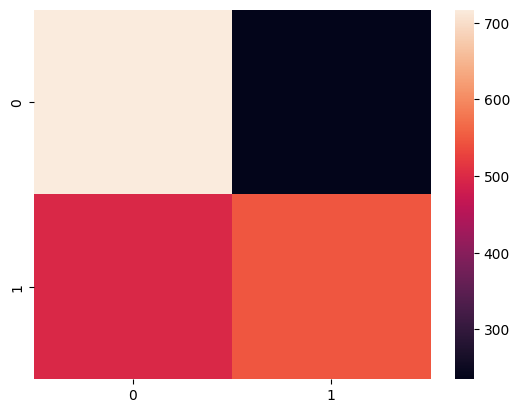

In [94]:
conf_matrix = confusion_matrix(y_test , y_pred )

print(conf_matrix)

sns.heatmap(conf_matrix)

RANDOM FOREST MODEL

Accuracy Score:  0.8492739108662994
[[811 141]
 [160 885]]


<Axes: >

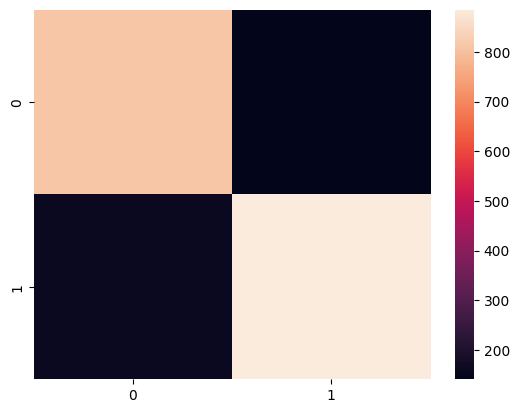

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(x_train_bow , y_train)

y_pred_rf = rf.predict( x_test_bow )

accuracy_rf = accuracy_score( y_test , y_pred_rf )

print("Accuracy Score: ",accuracy_rf)

conf_matrix_rf = confusion_matrix(y_test , y_pred_rf )

print(conf_matrix_rf)

sns.heatmap(conf_matrix_rf)

USING MAX FEATURES HYPERPARAMETER IN COUNT VECTORIZER

In [97]:
cv = CountVectorizer(max_features=3000)

X_train_bow = cv.fit_transform(x_train['review']).toarray()
X_test_bow = cv.transform(x_test['review']).toarray()

rf = RandomForestClassifier()

rf.fit(X_train_bow,y_train)
y_pred = rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

0.8442663995993991

N-GRAM method

In [98]:
cv = CountVectorizer(ngram_range=(1,2),max_features=5000)

X_train_bow = cv.fit_transform(x_train['review']).toarray()
X_test_bow = cv.transform(x_test['review']).toarray()

rf = RandomForestClassifier()

rf.fit(X_train_bow,y_train)
y_pred = rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

0.8482724086129194

USING TFIDF IN THE PIPELINE

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(x_train['review']).toarray()
X_test_tfidf = tfidf.transform(x_test['review'])
rf = RandomForestClassifier()

rf.fit(X_train_tfidf,y_train)
y_pred = rf.predict(X_test_tfidf)

accuracy_score(y_test,y_pred)

0.8482724086129194